# CONFIG

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2

from maikol_utils.print_utils import print_separator


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
from src.config.config import Configuration

CONFIG = Configuration()

# CODE

## Data

In [ ]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

files, n = list_dir_files(CONFIG.all_path, recursive=True)
print(f"Found {n} files in {CONFIG.all_path}")

Found 6899 files in data/NaturalImages/all
Selected 100 files for processing.


## Load trained model

In [27]:
from src.model import RowleyFaceNN, FaceCNN
from src.model import FaceDetectionModule, FaceDataModule

print("Loading:", CONFIG.best_cnn_model_path)

# path = CONFIG.best_cnn_model_path
path = os.path.join(CONFIG.MODELS_PATH, "best_cnn_model-v4.ckpt")
loaded_module = FaceDetectionModule.load_from_checkpoint(
    path,
    CONFIG=CONFIG,
    model=FaceCNN(
        in_channels=1 if CONFIG.gray_scale else 3,
        num_classes=1,
    ),
)
loaded_module.eval()
print("Model loaded successfully.")

Loading: models/best_cnn_model.ckpt
Model loaded successfully.


## Use model

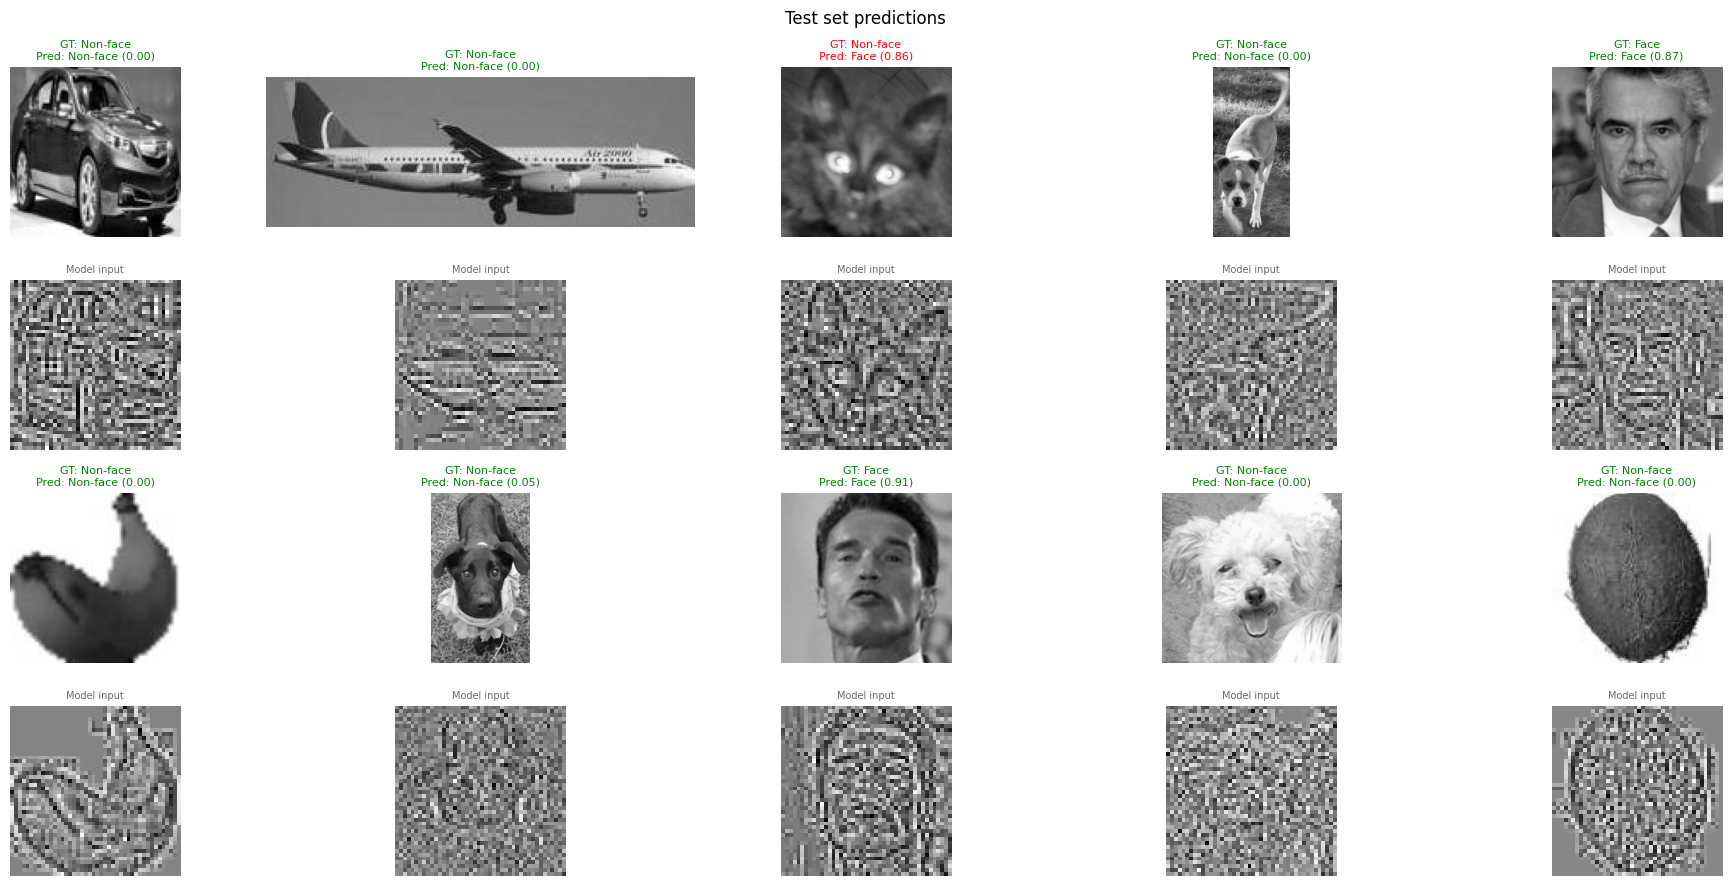

In [31]:
from maikol_utils.file_utils import list_dir_files
from src.data import local_normalize_image
import torchvision.transforms as transforms
import torch

test_paths, _ = list_dir_files(CONFIG.test_path)
# rng_inf = np.random.default_rng(CONFIG.seed+1)
# sample_paths = rng_inf.choice(test_paths, size=min(10, len(test_paths)), replace=False)
sample_paths = np.random.choice(test_paths, size=min(10, len(test_paths)), replace=False)

to_tensor = transforms.ToTensor()
device = next(loaded_module.parameters()).device

def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE if CONFIG.gray_scale else cv2.IMREAD_COLOR)
    if not CONFIG.gray_scale:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = local_normalize_image(CONFIG, img)
    
    # Rescale to [0, 255] — same as dataset.py
    img_min, img_max = img.min(), img.max() #-3, 3
    if img_max > img_min:
        img_uint8 = ((img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        img_uint8 = np.zeros_like(img_norm, dtype=np.uint8)
    img_resized = cv2.resize(img_uint8, (CONFIG.crop_size, CONFIG.crop_size), interpolation=cv2.INTER_AREA)
    tensor = to_tensor(Image.fromarray(img_resized))
    return tensor, img_resized

tensors, model_views = zip(*[preprocess(p) for p in sample_paths])

batch = torch.stack(tensors).to(device)
with torch.no_grad():
    # Model outputs raw logits — apply sigmoid to get probabilities in [0, 1]
    logits = loaded_module(batch).squeeze(1)
    probs = torch.sigmoid(logits).cpu().numpy()

# Layout: 5 images per logical row, 2 display rows each (original + model view)
n_imgs   = len(sample_paths)
cols     = min(5, n_imgs)
n_groups = int(np.ceil(n_imgs / cols))
n_rows   = n_groups * 2

fig, axes = plt.subplots(n_rows, cols, figsize=(4 * cols, 4.5 * n_groups))
axes = np.array(axes).reshape(n_rows, cols)

for i, (path, mv, prob) in enumerate(zip(sample_paths, model_views, probs)):
    grp_row  = i // cols
    col      = i  % cols
    orig_row = grp_row * 2
    view_row = grp_row * 2 + 1

    img_disp   = cv2.imread(path, cv2.IMREAD_GRAYSCALE if CONFIG.gray_scale else cv2.IMREAD_COLOR)
    gt_label   = "Face" if "person" in path else "Non-face"
    pred_label = "Face" if prob > 0.12 else "Non-face"
    correct    = gt_label == pred_label

    axes[orig_row, col].imshow(img_disp, cmap="gray" if CONFIG.gray_scale else None)
    axes[orig_row, col].set_title(f"GT: {gt_label}\nPred: {pred_label} ({prob:.2f})",
                                  color="green" if correct else "red", fontsize=8)
    axes[orig_row, col].axis("off")

    axes[view_row, col].imshow(mv, cmap="gray" if CONFIG.gray_scale else None)
    axes[view_row, col].set_title("Model input", fontsize=7, color="dimgray")
    axes[view_row, col].axis("off")

for col in range(n_imgs % cols or cols, cols):
    axes[n_rows - 2, col].axis("off")
    axes[n_rows - 1, col].axis("off")

plt.suptitle("Test set predictions", fontsize=12)
plt.tight_layout()
plt.show()


# Draw bounding boxes

In [ ]:
# [(x, y, w, h), ...]

faces = [(10, 20, 50, 50), (100, 150, 60, 60)]

In [ ]:
def draw_boxes(img, faces):
    for (x, y, w, h) in faces:
        # img, pt1, pt2, color (BGR), thickness
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return img
# 

boxes = draw_boxes(img_gray.copy(), faces)

cv2.imshow('Face Detection Result', boxes)
cv2.waitKey(0) 
cv2.destroyAllWindows()